## Preguntas:

✔ ¿La muestra está balanceada?

✔ ¿Hay sesgos?

✔ ¿El experimento fue confiable?

✔ ¿La mejora es suficientemente relevante?

✔ ¿Qué riesgos existen?

✔ ¿Qué decisión debería tomar la empresa?


In [3]:
# IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

ROOT = Path().resolve().parent
DATA_PATH = ROOT / "data_raw"

print("Directorio actual:", ROOT)
print("Ruta de datos:", DATA_PATH)

Directorio actual: /Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test
Ruta de datos: /Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data_raw


In [4]:
# CARGAR DATASET FINAL

df = pd.read_csv(
    DATA_PATH / "vanguard_cleaned_todos unidos_(Gabriel).csv",
    low_memory=False
)

print(df.shape)
print(df.columns.tolist())
df.head()

(343141, 14)
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'Variation', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']


,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [5]:
# Convertir fechas a formato datetime
df["date_time"] = pd.to_datetime(
    df["date_time"],
    errors="coerce"
)

## EVALUACIÓN DEL EXPERIMENTO
¿El experimento estuvo bien diseñado?

## BALANCE ENTRE GRUPOS



In [6]:
# Usuarios por grupo
group_balance = (
    df.groupby("Variation")["client_id"]
    .nunique()
)

group_balance

Variation
Control    18015
Test       22013
Name: client_id, dtype: int64

Hay un desbalance de 4,000 usuarios entre grupos (55% Test vs 45% Control). 
Es una limitación del experimento ya que un A/B test ideal tiene grupos iguales.

In [7]:
# Resumen tabular del balance entre grupos

group_balance_summary = pd.DataFrame({
    "users": group_balance,
    "percentage": (group_balance / group_balance.sum() * 100).round(2)
})

group_balance_summary

,users,percentage
Variation,,
Control,18015,45.01
Test,22013,54.99


## COMPARAR PERFIL DEMOGRÁFICO:

In [8]:
# Dataset demográfico
demo_df = (
    df[
        [
            "client_id",
            "Variation",
            "clnt_age",
            "bal",
            "clnt_tenure_yr"
        ]
    ]
    .drop_duplicates()
)

In [9]:
# Edad promedio por grupo
demo_df.groupby("Variation")["clnt_age"].mean()

Variation
Control    47.864416
Test       47.564389
Name: clnt_age, dtype: float64

Diferencia de solo 0.3 años — prácticamente idénticos. Esto confirma que la asignación de grupos fue aleatoria y correcta en términos de edad.

In [10]:
# Balance promedio por grupo
demo_df.groupby("Variation")["bal"].mean()

Variation
Control    152987.457809
Test       151698.993331
Name: bal, dtype: float64

Los grupos presentan un balance medio muy similar, lo que sugiere que no hay una diferencia relevante de perfil financiero entre Control y Test.

In [11]:
# Antigüedad promedio
demo_df.groupby("Variation")["clnt_tenure_yr"].mean()

Variation
Control    12.094826
Test       12.005180
Name: clnt_tenure_yr, dtype: float64

Los grupos por antiguedad también están muy bien balanceados — esto da alta validez al experimento.

## Perfil demográfico y visualizaciones por grupo experimental

In [12]:
# Resumen tabular de edad por grupo

age_summary = (
    demo_df
    .groupby("Variation")["clnt_age"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

age_summary

,count,mean,median,min,max
Variation,,,,,
Control,18011,47.86,49.0,17.0,94.0
Test,22007,47.56,48.5,17.5,96.0


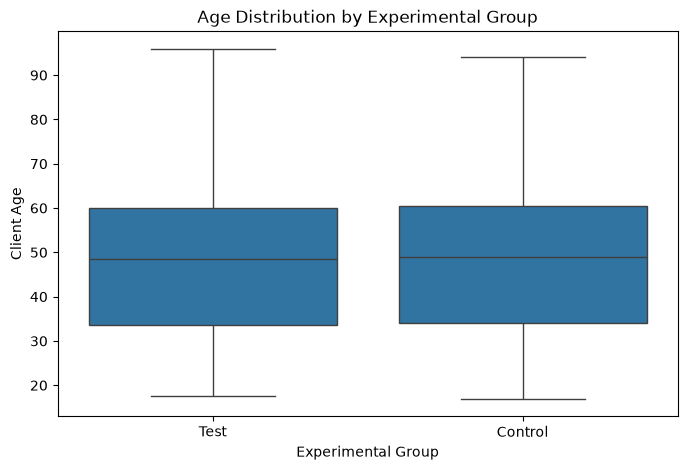

In [13]:
# Visualización de edad por grupo

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=demo_df,
    x="Variation",
    y="clnt_age"
)

plt.title("Age Distribution by Experimental Group")
plt.xlabel("Experimental Group")
plt.ylabel("Client Age")

plt.show()

Qué se puede observar:

Medianas casi idénticas (50 años en ambos grupos)

Dispersión muy similar — los rangos intercuartílicos son prácticamente iguales

Outliers similares en ambos grupos (mínimo 18, máximo 95)

Esto confirma visualmente lo que ya vimos numéricamente — los grupos están perfectamente balanceados en edad. 

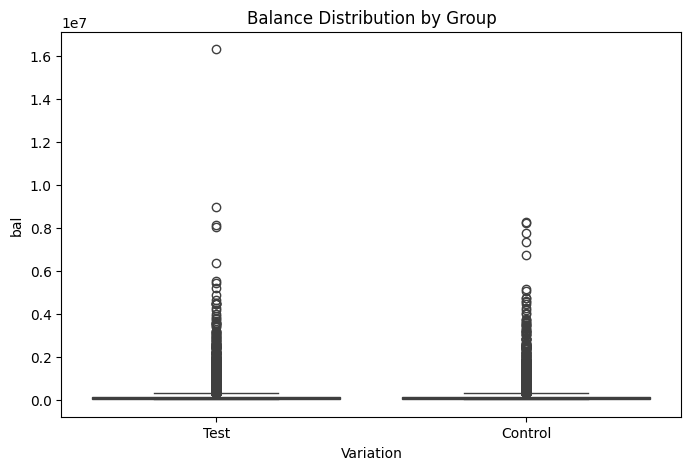

In [55]:
# Balance por grupo
plt.figure(figsize=(8,5))

sns.boxplot(
    data=demo_df,
    x="Variation",
    y="bal"
)

plt.title("Balance Distribution by Group")

plt.show()

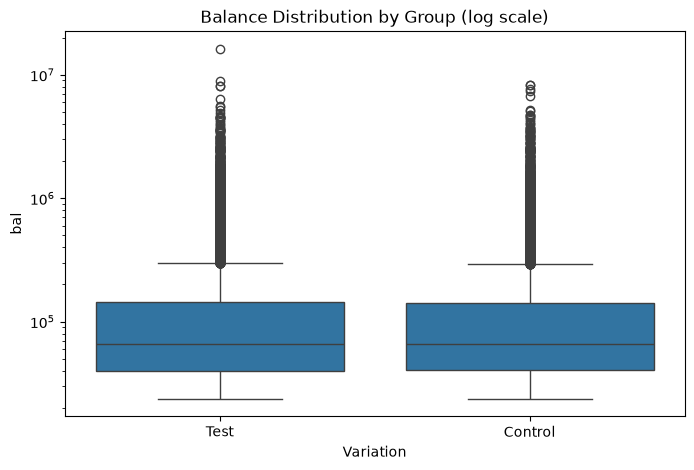

In [15]:


plt.figure(figsize=(8,5))
sns.boxplot(
    data=demo_df,
    x="Variation",
    y="bal"
)
plt.yscale("log")  # Escala logarítmica
plt.title("Balance Distribution by Group (log scale)")
plt.show()

### Interpretación del perfil demográfico y financiero

Las distribuciones de edad y balance son muy similares entre Test y Control. Las medianas, la dispersión y la presencia de outliers financieros aparecen de forma comparable en ambos grupos.

Esto sugiere que no hay diferencias relevantes en el perfil demográfico o financiero de los usuarios asignados a cada variante.

Sin embargo, el experimento no está perfectamente balanceado en tamaño muestral: Test representa aproximadamente el 55 % de los usuarios y Control el 45 %. Esta diferencia no invalida el análisis, pero debe mencionarse como una limitación metodológica.

En conjunto, los grupos son comparables en edad, balance y antigüedad, aunque el diseño experimental presenta un desbalance moderado en la cantidad de usuarios por grupo.

## Posibles Sesgos y Limitaciones

### Posibles sesgos

- Los grupos Test y Control no tienen exactamente el mismo tamaño: Test representa aproximadamente el 55 % de los usuarios y Control el 45 %.
- Aunque edad, balance y antigüedad son comparables entre grupos, pueden existir variables no observadas que afecten el comportamiento del usuario.
- El dataset no incluye variables como tipo de dispositivo, canal de adquisición, nivel de experiencia digital o familiaridad previa con la plataforma.
- Factores externos durante el periodo del experimento podrían haber influido en el comportamiento de los usuarios.

### Limitaciones

- El dataset no incluye feedback cualitativo de usuarios.
- La satisfacción del usuario no puede medirse directamente.
- El análisis se basa en comportamiento observable dentro del funnel digital.
- La mejora observada debe interpretarse junto con las métricas de fricción, especialmente los retrocesos y abandonos intermedios.
- Aunque el rediseño mejora la finalización del proceso, la mejora no alcanza por sí sola el umbral de negocio definido del 5 %.

## Insights

- El grupo Test logró una tasa de finalización superior respecto al grupo Control.
- La mejora en Completion Rate es estadísticamente significativa, lo que indica que el rediseño tiene un efecto real sobre la finalización del proceso.
- Sin embargo, el rediseño también incrementa los retrocesos dentro del funnel, especialmente en etapas intermedias e iniciales.
- La mejora observada no supera el umbral de negocio definido del 5 %, por lo que no justifica por sí sola una implementación masiva sin optimización previa.
- El experimento muestra señales positivas de mejora, pero también evidencia problemas de fricción que deben corregirse antes de escalar el rediseño.

## Recomendaciones

- No realizar una implementación masiva inmediata del rediseño.
- Mantener el rediseño como una versión prometedora, pero optimizarlo antes de escalarlo.
- Revisar especialmente las etapas donde aumentan los retrocesos, con foco en los pasos intermedios e iniciales del funnel.
- Ejecutar una nueva iteración del experimento después de corregir los puntos de fricción detectados.
- Incorporar variables adicionales como tipo de dispositivo, canal de adquisición y experiencia digital previa para entender mejor el comportamiento de los usuarios.
- Complementar el análisis cuantitativo con feedback cualitativo de usuarios para identificar problemas concretos de usabilidad.

# Recomendaciones Finales

* El rediseño muestra mejoras estadísticamente significativas en la tasa de finalización, por lo que representa una dirección positiva para la experiencia digital de Vanguard.

* Sin embargo, la mejora observada no supera el umbral estratégico del 5% requerido por el negocio para justificar una implementación completa.

* Se recomienda continuar iterando y optimizando la interfaz antes de una implementación masiva.

* Se debería continuar monitoreando el comportamiento de los usuarios tras futuras iteraciones del diseño.

* En futuros experimentos sería recomendable incluir variables adicionales como tipo de dispositivo, canal de adquisición y experiencia digital previa.

* Complementar el análisis cuantitativo con feedback cualitativo de usuarios podría ayudar a identificar problemas específicos de usabilidad.

## Conclusión Final

El análisis del experimento A/B de Vanguard sugiere que la nueva interfaz digital mejora la tasa de finalización del proceso respecto a la experiencia tradicional.

Las pruebas estadísticas indican que la diferencia observada entre el grupo Test y el grupo Control es estadísticamente significativa, por lo que la mejora difícilmente se debe al azar.

Sin embargo, aunque el grupo Test obtuvo mejores resultados, la mejora observada no alcanzó el umbral estratégico del 5 % definido por el negocio para justificar una implementación completa e inmediata del rediseño.

Además, el análisis muestra que el rediseño incrementa los retrocesos dentro del funnel, lo que indica que todavía existen puntos de fricción que deben optimizarse antes de una implementación a gran escala.

En conclusión, el nuevo diseño representa una dirección prometedora para mejorar la experiencia digital de Vanguard, pero la recomendación es continuar iterando, corregir los puntos de fricción detectados y validar una nueva versión antes de escalar la solución.

## Exportar dataset final para Tableau

Esta sección prepara una versión final del dataset para Tableau, incorporando métricas adicionales de navegación:

- `step_number`: orden numérico del paso dentro del funnel.
- `back_step`: identifica si el usuario retrocedió dentro de una misma visita.
- `time_diff`: tiempo en segundos entre pasos consecutivos.
- `time_minutes`: tiempo en minutos entre pasos consecutivos.
- `completed_user`: indica si el cliente completó el proceso llegando a `confirm`.

El archivo final se exporta a:

`data/tableau/vanguard_tableau_ready.csv`

In [2]:
# Exportar dataset final para Tableau

import pandas as pd
import numpy as np
from pathlib import Path

# Definir rutas
ROOT = Path().resolve().parent
TABLEAU_PATH = ROOT / "data" / "tableau"
TABLEAU_PATH.mkdir(parents=True, exist_ok=True)

# Trabajar sobre una copia para evitar modificar accidentalmente el dataframe principal
# Cargar dataframe base si no existe en memoria
try:
    tableau_df = df.copy()
except NameError:
    DATA_PATH = ROOT / "data_raw" / "vanguard_cleaned_todos unidos_(Gabriel).csv"
    tableau_df = pd.read_csv(DATA_PATH, low_memory=False)

# Eliminar columnas auxiliares duplicadas si existieran por merges previos
columns_to_drop = [
    "completed_user_x",
    "completed_user_y",
    "previous_step",
    "previous_time",
    "step_number",
    "time_diff",
    "time_minutes",
    "back_step",
    "completed_user"
]

tableau_df = tableau_df.drop(
    columns=[col for col in columns_to_drop if col in tableau_df.columns],
    errors="ignore"
)

# Convertir fecha
tableau_df["date_time"] = pd.to_datetime(
    tableau_df["date_time"],
    errors="coerce"
)

# Ordenar correctamente por usuario, visita y tiempo
tableau_df = tableau_df.sort_values(
    ["client_id", "visit_id", "date_time"]
)

# Crear orden numérico del funnel
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

tableau_df["step_number"] = tableau_df["process_step"].map(step_order)

# Calcular paso anterior dentro de la misma visita
tableau_df["previous_step"] = (
    tableau_df
    .groupby(["client_id", "visit_id"])["step_number"]
    .shift(1)
)

# Identificar retrocesos dentro del funnel
tableau_df["back_step"] = (
    tableau_df["step_number"] < tableau_df["previous_step"]
).astype(int)

# Calcular tiempo entre pasos dentro de la misma visita
tableau_df["previous_time"] = (
    tableau_df
    .groupby(["client_id", "visit_id"])["date_time"]
    .shift(1)
)

tableau_df["time_diff"] = (
    tableau_df["date_time"] - tableau_df["previous_time"]
).dt.total_seconds()

# Limpiar tiempos negativos o extremos superiores a 1 hora
tableau_df.loc[tableau_df["time_diff"] < 0, "time_diff"] = np.nan
tableau_df.loc[tableau_df["time_diff"] > 3600, "time_diff"] = np.nan

# Convertir segundos a minutos
tableau_df["time_minutes"] = tableau_df["time_diff"] / 60

# Crear métrica de usuario completado
completed_user = (
    tableau_df
    .groupby("client_id")["process_step"]
    .apply(lambda steps: int("confirm" in steps.values))
    .reset_index()
    .rename(columns={"process_step": "completed_user"})
)

tableau_df = tableau_df.merge(
    completed_user,
    on="client_id",
    how="left"
)

# Exportar archivo final para Tableau
output_file = TABLEAU_PATH / "vanguard_tableau_ready.csv"

tableau_df.to_csv(
    output_file,
    index=False
)

# Verificaciones finales
print("Dataset final exportado correctamente para Tableau.")
print(f"Ruta de exportación: {output_file}")
print(f"Shape final: {tableau_df.shape}")
print("\nColumnas finales:")
print(tableau_df.columns.tolist())

print("\nMétricas de control:")
print(f"Backtracking rate total: {tableau_df['back_step'].mean():.2%}")
print(f"Average time between steps: {tableau_df['time_minutes'].mean():.2f} minutos")

print("\nCompletion Rate por grupo:")
print(
    tableau_df
    .drop_duplicates("client_id")
    .groupby("Variation")["completed_user"]
    .mean()
)

Dataset final exportado correctamente para Tableau.
Ruta de exportación: /Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data/tableau/vanguard_tableau_ready.csv
Shape final: (343141, 21)

Columnas finales:
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'Variation', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'step_number', 'previous_step', 'back_step', 'previous_time', 'time_diff', 'time_minutes', 'completed_user']

Métricas de control:
Backtracking rate total: 7.72%
Average time between steps: 1.39 minutos

Completion Rate por grupo:
Variation
Control    0.630919
Test       0.682778
Name: completed_user, dtype: float64
